# River Brain: Phase 1 feasibility

**Question:** can we explain the water level under a floating home on Hayden Island
as *tide + Bonneville Dam release + everything else*, using only free public data,
well enough to tell someone *why the river is rising or falling right now*?

**Gauge:** USGS 14144700, Columbia River at Vancouver, WA (at the I-5 bridge, directly
across the channel from Hayden Island). River mile ~106.5. Bonneville Dam is at river
mile ~146, so the dam is ~40 river miles upstream. The Willamette enters at Kelley
Point (RM ~101), *downstream* of the gauge, but backs water up past it.

**Sections**
1. Fetch data (all five sources + Willamette + Astoria)
2. Bonneville data QC (gaps, spikes, flatlines) and Dataquery vs CDA
3. Datums: why three "stages" for the same spot disagree
4. The tide signal and a trap in NOAA's river-tide predictions
5. The model as specified: tide + lagged Bonneville + slow residual
6. Travel time from Bonneville to Vancouver
7. A model ladder: what each physical term buys, in and out of sample
8. Where the model breaks down
9. Prototype of the production output: "why is the river moving?"
10. NWS forecast and fish counts feasibility

All times are stored in UTC; plots show Pacific time. Stage is in feet above the USGS
gage datum unless noted. Flows in kcfs (thousand cubic feet per second).

In [1]:
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import sources as S

FIG = Path("../docs/figures")
FIG.mkdir(parents=True, exist_ok=True)
TZ = "America/Los_Angeles"

# One color per physical component, used everywhere (and later in the app).
C = dict(obs="#0b0b0b", model="#2a78d6", tide="#2a78d6", bon="#eb6834", wil="#1baf7a",
         sn="#4a3aa7", ocean="#e87ba4", resid="#8a8983", grid="#e4e3df", muted="#52514e")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 130, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#b5b4ae",
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.6, "axes.axisbelow": True,
    "lines.linewidth": 1.3, "font.size": 9.5, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "text.color": "#0b0b0b",
    "axes.labelcolor": C["muted"], "xtick.color": C["muted"], "ytick.color": C["muted"],
})


def local(idx):
    return idx.tz_convert(TZ)


def fmt_dates(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d", tz=TZ))


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

## 1. Fetch data

We pull **Mar 1 – Sep 23, 2026** once and slice analysis windows from it. That covers
the spring freshet (Bonneville ~240 kcfs) and the late-summer low (~75 kcfs), so we
can test the model in both regimes. The request asked for the last 30 days; that
window alone can't answer "where does it break down at high flow", because late
September is near the annual minimum.

Raw responses are cached in `data/raw/` (set `RB_REFRESH=1` to re-download).
Fetcher code is in `sources.py` next to this notebook.

In [2]:
START, END = "2026-03-01", "2026-09-24"
H = pd.date_range(START, END, freq="h", tz="UTC", inclusive="left")  # hourly UTC grid
W = {  # analysis windows
    "recent (Aug 24–Sep 23)": ("2026-08-24", "2026-09-24"),
    "freshet (Apr 25–Jun 25)": ("2026-04-25", "2026-06-25"),
    "season (Mar 1–Sep 23)": (START, END),
}
W = {k: (pd.Timestamp(a, tz="UTC"), pd.Timestamp(b, tz="UTC")) for k, (a, b) in W.items()}

stage15 = S.usgs_continuous("14144700", "00065", START, END)          # 15-min gage height, ft
wil15 = S.usgs_continuous("14211720", "00060", START, END)            # Willamette Q, 5-min, cfs (reverses with tide)
wil_filt = S.usgs_continuous("14211720", "72137", START, END)         # USGS tide-filtered Q, cfs
van_filt = S.usgs_continuous("14144700", "72137", START, END)         # Columbia at Vancouver, filtered Q
pred6 = S.noaa_series("predictions", "9440083", START, "2026-09-27")  # Vancouver tide predictions, ft MLLW (3 days ahead, as production would)
wl6 = S.noaa_series("water_level", "9440083", "2026-08-24", END)      # Vancouver observed, ft MLLW
ast_pred = S.noaa_series("predictions", "9439040", START, END)        # Astoria (ocean end)
ast_obs = S.noaa_series("water_level", "9439040", START, END)
bon_dq = S.usace_dataquery(START, END)                                # kcfs
bon_cda = S.usace_cda(START, END)                                     # kcfs + quality
nwps_obs, nwps_fcst = S.nwps_stageflow(snapshot="20260924T00")
nwps_meta = S.nwps_gauge()
fish = S.dart_adult_daily(2026, "1/1", "12/31", avg=True)


def coverage(name, s, step):
    s = s.dropna()
    exp = int((s.index.max() - s.index.min()) / pd.Timedelta(step)) + 1
    return dict(source=name, first=s.index.min().strftime("%Y-%m-%d %H:%M"),
                last=s.index.max().strftime("%Y-%m-%d %H:%M"), n=len(s), expected=exp,
                pct=round(100 * len(s) / exp, 1))


pd.DataFrame([
    coverage("USGS stage 15-min", stage15.value, "15min"),
    coverage("USGS Willamette Q 5-min", wil15.value, "5min"),
    coverage("USGS Willamette tide-filtered Q", wil_filt.value, "1h"),
    coverage("NOAA Vancouver predictions", pred6[:END], "6min"),
    coverage("NOAA Vancouver observed", wl6, "6min"),
    coverage("NOAA Astoria observed", ast_obs, "6min"),
    coverage("USACE Dataquery BON outflow", bon_dq, "1h"),
    coverage("USACE CDA BON outflow", bon_cda.kcfs, "1h"),
    coverage("NWPS VAPW1 observed", nwps_obs, "6min"),
]).set_index("source")

,first,last,n,expected,pct
source,,,,,
USGS stage 15-min,2026-03-01 00:00,2026-09-24 00:00,19856,19873,99.9
USGS Willamette Q 5-min,2026-03-01 00:00,2026-09-24 00:00,59238,59617,99.4
USGS Willamette tide-filtered Q,2026-03-01 00:00,2026-09-22 12:00,4699,4933,95.3
NOAA Vancouver predictions,2026-03-01 00:00,2026-09-24 23:54,49920,49920,100.0
NOAA Vancouver observed,2026-08-24 00:00,2026-09-24 00:00,7441,7441,100.0
NOAA Astoria observed,2026-03-01 00:00,2026-09-24 00:00,49681,49681,100.0
USACE Dataquery BON outflow,2026-03-01 00:00,2026-09-23 22:00,4967,4967,100.0
USACE CDA BON outflow,2026-03-01 00:00,2026-09-24 00:00,4896,4969,98.5
NWPS VAPW1 observed,2026-08-25 01:06,2026-09-24 00:36,7116,7196,98.9


**Latency matters for production.** The USGS *tide-filtered* discharge (parameter 72137)
uses a centered filter, so it trails real time by about two days:

In [3]:
now = pd.Timestamp("2026-09-24 00:30", tz="UTC")
pd.Series({
    "USGS stage": stage15.index.max(), "USGS Willamette Q (raw)": wil15.index.max(),
    "USGS Willamette Q (tide-filtered)": wil_filt.index.max(),
    "USGS Columbia Q (tide-filtered)": van_filt.index.max(), "BON outflow": bon_dq.index.max(),
}).map(lambda t: f"{t:%Y-%m-%d %H:%M} UTC  ({(now - t).total_seconds() / 3600:.0f} h behind)").to_frame("latest value")

,latest value
USGS stage,2026-09-24 00:00 UTC (0 h behind)
USGS Willamette Q (raw),2026-09-24 00:00 UTC (0 h behind)
USGS Willamette Q (tide-filtered),2026-09-22 12:00 UTC (36 h behind)
USGS Columbia Q (tide-filtered),2026-09-22 13:00 UTC (36 h behind)
BON outflow,2026-09-23 22:00 UTC (2 h behind)


So the hourly production job can't use 72137. Every flow-derived feature below is built
**causally** (trailing windows only) from real-time series, so the model tested here is
the one production can actually run.

## 2. Bonneville outflow QC

USACE hourly outflow is known to contain gaps and occasional bad values. The QC flags:

| flag | rule | why |
|---|---|---|
| `missing` | hour absent or null after reindexing to a full hourly grid | Dataquery drops rows, CDA returns nulls |
| `range` | outside 10–700 kcfs | physically impossible at Bonneville (record ≈ 600 kcfs) |
| `spike` | deviates from the 7-h centered median by > max(25 kcfs, 6×robust σ) | isolated one-to-two-hour glitches; real operational changes are steps, which a median follows. These are *suspect*, not proven bad |
| `flat` | same value repeated ≥ 8 hours | stuck telemetry (hourly averages to 0.1 kcfs rarely repeat that long) |

Bad values are masked, then gaps of ≤ 3 h are linearly interpolated. Longer gaps stay
NaN, and the model skips those hours (production will report "dam data unavailable").

In [4]:
def fill_short_gaps(s, max_len):
    """Linearly interpolate interior NaN runs of <= max_len; leave longer runs untouched.
    (pandas' interpolate(limit=n) would fill the first n hours of a long gap.)"""
    isna = s.isna()
    run_id = (isna != isna.shift()).cumsum()
    run_len = isna.groupby(run_id).transform("size")
    fillable = isna & (run_len <= max_len)
    return s.where(~fillable, s.interpolate(limit_area="inside"))


def qc_flow(s, lo=10, hi=700, spike_kcfs=25, spike_k=6, flat_hours=8, max_fill=3):
    """Return (clean hourly series, per-hour flag table)."""
    full = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq="h"))
    f = pd.DataFrame(index=full.index)
    f["missing"] = full.isna()
    f["range"] = (full < lo) | (full > hi)
    med = full.rolling(7, center=True, min_periods=3).median()
    dev = (full - med).abs()
    robust_sigma = 1.4826 * dev.rolling(7 * 24, center=True, min_periods=24).median()
    f["spike"] = dev > np.maximum(spike_kcfs, spike_k * robust_sigma)
    runs = (full.diff() != 0).cumsum()
    f["flat"] = full.groupby(runs).transform("size").ge(flat_hours) & full.notna()
    bad = f[["range", "spike", "flat"]].any(axis=1)
    clean = fill_short_gaps(full.mask(bad), max_fill)
    f["filled"] = clean.notna() & (full.isna() | bad)
    f["still_missing"] = clean.isna()
    return clean, f


dq_clean, dq_flags = qc_flow(bon_dq)
cda_clean, cda_flags = qc_flow(bon_cda.kcfs)
pd.DataFrame({"Dataquery": dq_flags.sum(), "CDA": cda_flags.sum()}).T

,missing,range,spike,flat,filled,still_missing
Dataquery,0,0,2,0,2,0
CDA,73,0,2,0,2,73


No range or flatline problems this season. Two hours were flagged as spikes, shown
below. Both are short dips of 30–40 kcfs that recover within 1–2 hours. They could be
telemetry glitches or genuine short events (for example a turbine unit tripping
offline), and we can't tell from this data alone. Masking and interpolating them has
negligible effect on the model, which averages Bonneville flow over many hours
(Section 7).

In [5]:
for t in dq_flags.index[dq_flags.spike]:
    print(bon_dq[t - pd.Timedelta("4h"):t + pd.Timedelta("3h")].round(1).to_string(), end="\n\n")

2026-04-10 04:00:00+00:00    198.8
2026-04-10 05:00:00+00:00    195.1
2026-04-10 06:00:00+00:00    192.0
2026-04-10 07:00:00+00:00    172.2
2026-04-10 08:00:00+00:00    157.9
2026-04-10 09:00:00+00:00    190.6
2026-04-10 10:00:00+00:00    190.3
2026-04-10 11:00:00+00:00    190.5

2026-04-24 14:00:00+00:00    273.4
2026-04-24 15:00:00+00:00    270.9
2026-04-24 16:00:00+00:00    280.0
2026-04-24 17:00:00+00:00    260.5
2026-04-24 18:00:00+00:00    240.6
2026-04-24 19:00:00+00:00    262.3
2026-04-24 20:00:00+00:00    267.1
2026-04-24 21:00:00+00:00    265.6



To show the QC actually works, inject the kinds of faults USACE data is known for into
a copy:

In [6]:
rng = np.random.default_rng(0)
test = bon_dq.copy()
t0 = test.index[2000]
test.iloc[2000] = 0.0                              # zero dropout
test.iloc[2300] += 60                              # one-hour spike
test.iloc[2600:2612] = test.iloc[2600]             # 12-hour stuck value
test = test.drop(test.index[2900:2902])            # 2-hour hole (short: fill)
test = test.drop(test.index[3100:3110])            # 10-hour hole (long: leave)
test.iloc[3300] = -999.0                           # sentinel value
_, tf = qc_flow(test)
injected = tf[tf[["missing", "range", "spike", "flat"]].any(axis=1)]
print("hours flagged:", len(injected))
injected.groupby((injected.index.to_series().diff() != pd.Timedelta("1h")).cumsum()).agg(
    start=("missing", lambda x: x.index[0].strftime("%m-%d %H:%M")), hours=("missing", "size"),
    missing=("missing", "sum"), range=("range", "sum"), spike=("spike", "sum"), flat=("flat", "sum"),
    filled=("filled", "sum")).set_index("start")

hours flagged: 29


,hours,missing,range,spike,flat,filled
start,,,,,,
04-10 08:00,1,0,0,1,0,1
04-24 18:00,1,0,0,1,0,1
05-23 08:00,1,0,1,1,0,1
06-04 20:00,1,0,0,1,0,1
06-17 08:00,12,0,0,0,12,0
06-29 20:00,2,2,0,0,0,2
07-08 06:00,10,10,0,0,0,0
07-17 00:00,1,0,1,1,0,1


Every injected fault is caught (the two real suspect spikes also appear). Short holes
(≤ 3 h) are filled; the 10-hour hole and the 12-hour stuck run stay missing.

**Dataquery vs CDA.** Both serve the same USACE CWMS database:

In [7]:
j = pd.concat([bon_dq.rename("dq"), bon_cda.kcfs.rename("cda")], axis=1)  # raw values
both = j.dropna()
gaps_cda = j[j.cda.isna() & j.dq.notna()]
runs = gaps_cda.index.to_series().diff().ne(pd.Timedelta("1h")).cumsum()
print(f"hours in both: {len(both)};  max |difference|: {(both.dq - both.cda).abs().max():.3f} kcfs")
print(f"hours only in Dataquery: {len(gaps_cda)} in {runs.nunique()} runs "
      f"({', '.join(f'{g.index[0]:%b %d %H:%M} ({len(g)} h)' for _, g in gaps_cda.groupby(runs))})")
print(f"hours only in CDA: {int((j.dq.isna() & j.cda.notna()).sum())}")

hours in both: 4894;  max |difference|: 0.000 kcfs
hours only in Dataquery: 73 in 3 runs (Jun 12 22:00 (38 h), Jun 15 07:00 (15 h), Jun 15 23:00 (20 h))
hours only in CDA: 2


Where both have data they agree exactly. CDA has three multi-hour holes in June where
Dataquery has smooth, plausible values. **Production:** use Dataquery as primary,
fill any holes from CDA (`combine_first`), then QC. Dataquery needs the pinned DigiCert
intermediate certificate (see `sources.py`); CDA has a valid chain.

In [8]:
bon = dq_clean.combine_first(cda_clean).reindex(H)
bon, bon_flags = qc_flow(bon.dropna())
bon = bon.reindex(H)

## 3. Datums

Three agencies report water level at essentially the same spot, each on its own zero:

* **USGS 14144700** gage height: gage datum is 1.82 ft above NGVD29.
* **NOAA 9440083**: we requested MLLW (tidal datum, epoch 1983–2001).
* **NWPS VAPW1**: the NWS forecast point. Flood stages (action 15 ft, minor 16 ft,
  moderate 20 ft, major 25 ft) are in *its* datum.

If the difference between two series is a pure offset, its standard deviation should be
near zero:

In [9]:
stage = stage15.value.reindex(H)  # instantaneous value at the top of each hour
wl_h = wl6.reindex(H)
nw_h = nwps_obs.reindex(H)
rw = slice(*W["recent (Aug 24–Sep 23)"])
off = pd.DataFrame({
    "NWPS obs − USGS": (nw_h - stage)[rw], "USGS − NOAA obs (MLLW)": (stage - wl_h)[rw],
}).describe().T[["count", "mean", "std", "min", "max"]].round(3)
off

,count,mean,std,min,max
NWPS obs − USGS,712.0,0.128,0.06,0.02,0.280
USGS − NOAA obs (MLLW),744.0,1.690,0.06,1.54,1.812


NWPS observed stage sits ~0.13 ft above USGS with ~0.06 ft scatter (sampling time and
sensor noise). So **NWS forecasts and flood stages can be compared with USGS gage
height after a ~0.1 ft adjustment.** NOAA's gauge relates to USGS by a larger offset; we
don't need NOAA's observed level, only its predictions, and the model fits its own
intercept.

## 4. The tide signal, and a trap

NOAA's Vancouver "tide prediction" is a harmonic fit to the station's history. At a
river station the harmonic set includes long-period terms (annual Sa, semi-annual Ssa)
that stand in for the *average seasonal river flow*. Using the predictions raw would
count river flow twice: once in "tide", again in "Bonneville".

Fix: split the prediction with a **Godin filter** (24 h, 24 h, 25 h moving averages in
sequence, the standard tidal low-pass). The high-pass part is the pure tidal
oscillation; the low-pass part is NOAA's built-in seasonal river assumption, which we
discard. Predictions exist into the future, so this centered filter is usable in
production.

low-pass part of the prediction ranges 0.79 to 1.60 ft over the season


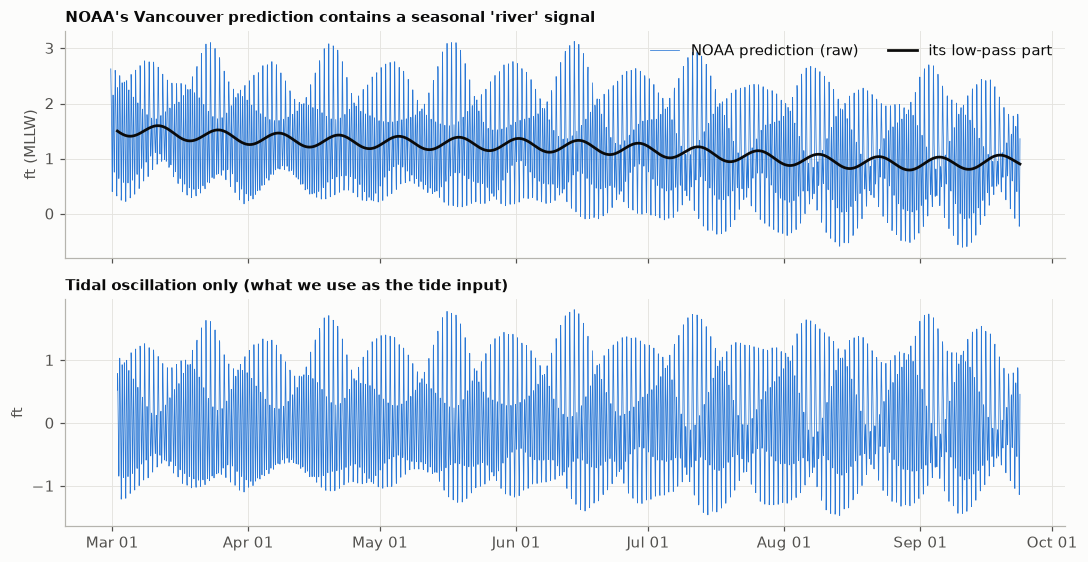

In [10]:
def godin(x):
    return x.rolling(24, center=True).mean().rolling(24, center=True).mean().rolling(25, center=True).mean()


def hilbert(x):
    """Analytic signal via FFT (equivalent to scipy.signal.hilbert)."""
    n = len(x)
    h = np.zeros(n)
    h[0] = 1
    if n % 2 == 0:
        h[n // 2] = 1
        h[1:n // 2] = 2
    else:
        h[1:(n + 1) // 2] = 2
    return np.fft.ifft(np.fft.fft(x) * h)


HX = pd.date_range(START, "2026-09-27", freq="h", tz="UTC", inclusive="left")  # extended grid for tide terms
pred_x = pred6.reindex(HX)
pred = pred_x.reindex(H)
pred_low = godin(pred_x).reindex(H)
tide_osc = pred - pred_low

fig, ax = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
ax[0].plot(local(H), pred, color=C["tide"], lw=0.5, label="NOAA prediction (raw)")
ax[0].plot(local(H), pred_low, color=C["obs"], lw=1.8, label="its low-pass part")
ax[0].set_title("NOAA's Vancouver prediction contains a seasonal 'river' signal")
ax[0].set_ylabel("ft (MLLW)")
ax[0].legend(loc="upper right", ncol=2)
ax[1].plot(local(H), tide_osc, color=C["tide"], lw=0.5)
ax[1].set_title("Tidal oscillation only (what we use as the tide input)")
ax[1].set_ylabel("ft")
fmt_dates(ax[1])
fig.tight_layout()
savefig(fig, "04_tide_split")
print(f"low-pass part of the prediction ranges {pred_low.min():.2f} to {pred_low.max():.2f} ft over the season")

The discarded low-pass part does two things. It declines ~0.8 ft from March to
September, which is NOAA's assumed *typical* seasonal river; our model uses the *actual*
river instead. It also oscillates every ~14.8 days: the MSf constituent, NOAA's
flow-averaged version of spring–neap "tidal setup". We estimate that effect directly in
Section 7 (term M5). The fact that NOAA's harmonic analysis found it too corroborates
that the effect is real.

We also compute the **quadrature** (90°-shifted) tide with a Hilbert transform. A
combination `a·T + p·H(T)` can then shift the tide's timing as well as scale its size,
which matters because river flow both damps the tide and delays it. The **envelope**
|T + iH(T)| tracks the spring–neap cycle.

In [11]:
osc_x = pred_x - godin(pred_x)
m = osc_x.notna()
an = pd.Series(np.nan + 0j, index=HX)
an[m] = hilbert(osc_x[m].to_numpy())
tide_q = pd.Series(np.imag(an), index=HX).where(m).reindex(H)
tide_env = pd.Series(np.abs(an), index=HX).where(m)
spring_neap = godin(tide_env).reindex(H)
spring_neap = spring_neap - spring_neap.mean()

## 5. The model as specified

$$\text{stage}(t) = c + a\,T(t) + b\,Q_{BON}(t-\tau) + r(t)$$

with $T$ the tidal oscillation and $r$ the leftover. Fit by ordinary least squares for
every lag τ = 0…48 h and keep the best.

Three ways to score it, because a leftover defined as "whatever's left" makes R²
meaningless on its own:

* **(a) R² of tide + Bonneville alone:** how much the two named drivers explain.
* **(b) R² with the slow residual added back:** the Godin-filtered leftover, i.e. the
  "everything else" term. This is nearly 1 by construction; it shows how much of the
  leftover is slow (explainable as runoff/baseline) versus fast (model error).
* **(c) out-of-sample R²:** choose τ and fit on the first ⅔ of the window, score the
  last ⅓. This is the honest number.

In [12]:
def ols(df, cols, y="y"):
    d = df.dropna(subset=cols + [y])
    X = np.column_stack([np.ones(len(d))] + [d[c].to_numpy() for c in cols])
    beta, *_ = np.linalg.lstsq(X, d[y].to_numpy(), rcond=None)
    return pd.Series(beta, index=["const"] + cols), d


def predict(beta, df):
    cols = [c for c in beta.index if c != "const"]
    return beta["const"] + (df[cols] * beta[cols]).sum(axis=1, min_count=len(cols))


def r2(y, yhat):
    ok = y.notna() & yhat.notna()
    y, yhat = y[ok], yhat[ok]
    return 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def rmse(y, yhat):
    return float(np.sqrt(((y - yhat) ** 2).mean()))


def spec_features(tau):
    return pd.DataFrame({"y": stage, "T": tide_osc, "q": bon.shift(tau)})


rows, scans = [], {}
for name, (a, b) in W.items():
    scan = pd.Series({tau: r2(*(lambda beta, d: (d.y, predict(beta, d)))(*ols(spec_features(tau)[a:b], ["T", "q"])))
                      for tau in range(0, 49)})
    scans[name] = scan
    tau = int(scan.idxmax())
    beta, d = ols(spec_features(tau)[a:b], ["T", "q"])
    yhat = predict(beta, d)
    slow = godin(d.y - yhat)
    # out of sample: choose tau on training data only
    cut = a + (b - a) * 2 / 3
    tr_scan = {t: r2(*(lambda beta, d: (d.y, predict(beta, d)))(*ols(spec_features(t)[a:cut], ["T", "q"])))
               for t in range(0, 49)}
    t_tr = max(tr_scan, key=tr_scan.get)
    b_tr, _ = ols(spec_features(t_tr)[a:cut], ["T", "q"])
    te = spec_features(t_tr)[cut:b].dropna()
    rows.append({"window": name, "best τ (h)": tau, "tide gain a": beta["T"], "b (ft/kcfs)": beta["q"],
                 "(a) R² tide+BON": r2(d.y, yhat), "(b) R² + slow resid": r2(d.y, yhat + slow),
                 "(c) out-of-sample R²": r2(te.y, predict(b_tr, te)), "RMSE (ft)": rmse(d.y, yhat)})
spec_table = pd.DataFrame(rows).set_index("window").round(3)
spec_table

,best τ (h),tide gain a,b (ft/kcfs),(a) R² tide+BON,(b) R² + slow resid,(c) out-of-sample R²,RMSE (ft)
window,,,,,,,
recent (Aug 24–Sep 23),17,1.512,0.024,0.856,0.933,0.554,0.448
freshet (Apr 25–Jun 25),11,0.766,0.024,0.759,0.906,0.679,0.530
season (Mar 1–Sep 23),8,1.025,0.030,0.808,0.962,0.531,0.908


Plots for the recent window. The four component panels share a y-scale, so their
heights are directly comparable.

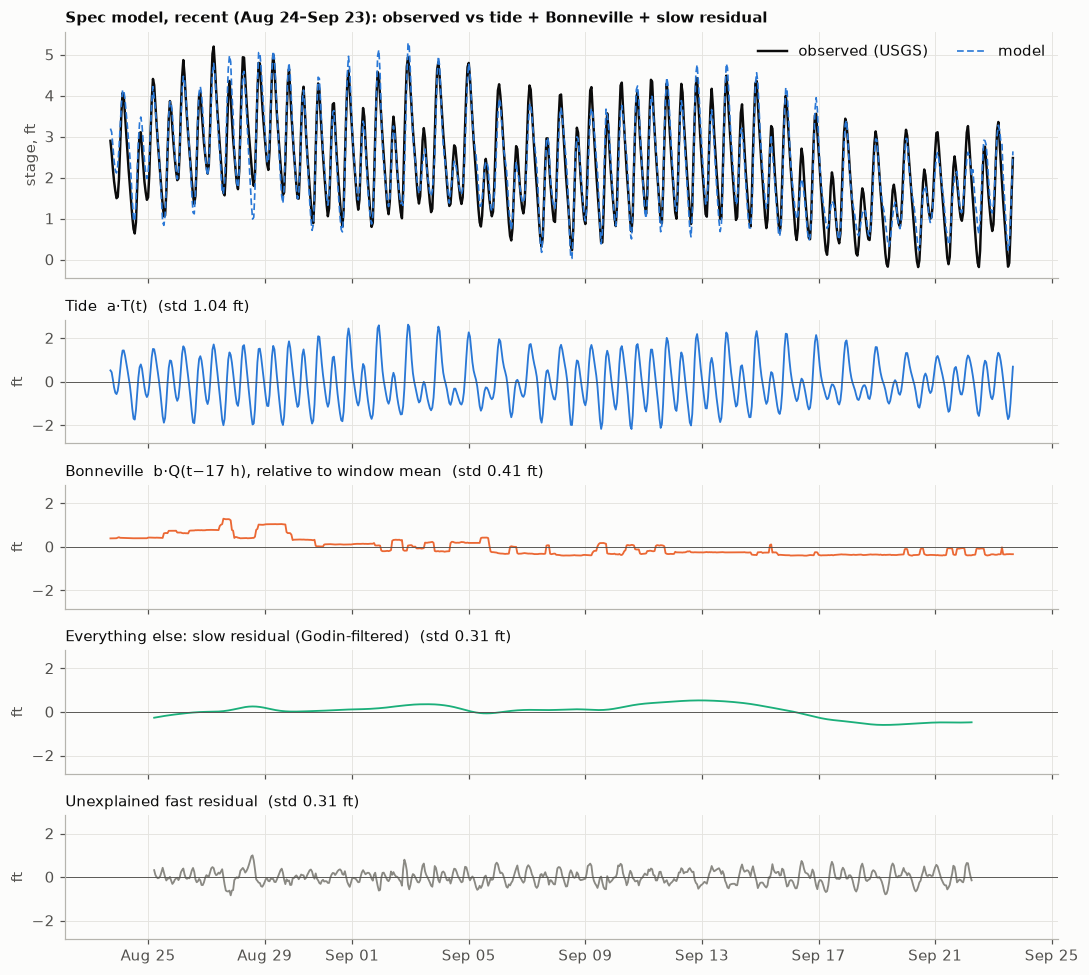

In [13]:
def component_figure(name, comps, obs, model, title, fname):
    fig, ax = plt.subplots(len(comps) + 1, 1, figsize=(10, 1.55 * (len(comps) + 1) + 1.2), sharex=True,
                           gridspec_kw=dict(height_ratios=[2] + [1] * len(comps)))
    grid = pd.date_range(obs.index.min(), obs.index.max(), freq="h")  # reindex so data gaps show as gaps
    obs, model = obs.reindex(grid), model.reindex(grid)
    comps = [(lab, v.reindex(grid), col) for lab, v, col in comps]
    t = local(grid)
    ax[0].plot(t, obs, color=C["obs"], lw=1.6, label="observed (USGS)")
    ax[0].plot(t, model, color=C["model"], lw=1.1, ls=(0, (4, 2)), label="model")
    ax[0].set_title(title)
    ax[0].set_ylabel("stage, ft")
    ax[0].legend(loc="upper right", ncol=2)
    lim = max(float(np.nanmax(np.abs(v.to_numpy()))) for _, v, _ in comps) * 1.08
    for axi, (label, v, col) in zip(ax[1:], comps):
        axi.plot(local(v.index), v, color=col, lw=1.2)
        axi.axhline(0, color=C["muted"], lw=0.6)
        axi.set_ylim(-lim, lim)
        axi.set_ylabel("ft")
        axi.set_title(f"{label}  (std {np.nanstd(v):.2f} ft)", fontweight="normal", color=C["obs"])
    fmt_dates(ax[-1])
    fig.tight_layout()
    savefig(fig, fname)
    return fig


name = "recent (Aug 24–Sep 23)"
a, b = W[name]
tau = int(scans[name].idxmax())
beta, d = ols(spec_features(tau)[a:b], ["T", "q"])
yhat = predict(beta, d)
resid = d.y - yhat
slow = godin(resid)
bon_c = beta["q"] * d.q
component_figure(name, [
    ("Tide  a·T(t)", beta["T"] * d["T"], C["tide"]),
    (f"Bonneville  b·Q(t−{tau} h), relative to window mean", bon_c - bon_c.mean(), C["bon"]),
    ("Everything else: slow residual (Godin-filtered)", slow, C["wil"]),
    ("Unexplained fast residual", resid - slow, C["resid"]),
], d.y, yhat + slow.fillna(0), f"Spec model, {name}: observed vs tide + Bonneville + slow residual", "05_spec_components");

**Reading this:**
* Tide dominates day to day in late summer (±1.5 ft swings).
* The Bonneville component is real but small at these flows. Daily dam load-following
  of ±20 kcfs becomes a few tenths of a foot here.
* The fast residual still contains clear tidal-period wiggles. The NOAA tide is the
  wrong *size* and *timing* for the current flow (Section 8), and a plain `a·T` can't fix
  timing.
* The out-of-sample R² is much lower than in-sample, and the best lag moves around between
  windows. The spec model is **not** yet trustworthy for attributing "why", which leads
  to Sections 6 and 7.

## 6. Travel time from Bonneville

Fitting τ inside the full model gives a flat, noisy R²(τ) curve: slow flow changes are
only weakly lag-sensitive, and tide residuals swamp the dam's hourly fluctuations. Three
better-conditioned estimates:

1. **R²(τ) curves** from the spec model, per window (below, left).
2. **Band-pass cross-correlation:** keep only 30 h – 10 day periods in both stage and
   Bonneville outflow. That removes tides and the seasonal trend while keeping the dam's
   weekday/weekend cycle, then finds the lag of peak correlation (below, right).
3. **Response kernel:** in the full model (Section 7), Bonneville enters as a *trailing
   average* of Q over w hours, starting τ hours back. A flood wave spreads out as it
   travels, so a smeared response is physically expected. The centroid lag is τ + (w−1)/2.

,spec R² peak (h),band-pass xcorr peak (h),peak correlation
recent (Aug 24–Sep 23),17,9,0.804
freshet (Apr 25–Jun 25),11,14,0.836
season (Mar 1–Sep 23),8,11,0.748


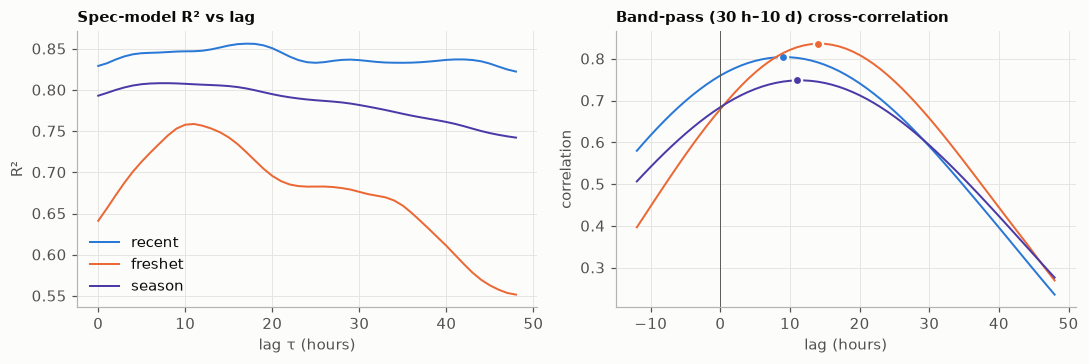

In [14]:
def bandpass(x):
    return godin(x) - x.rolling(240, center=True, min_periods=200).mean()


fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
xc = {}
for (name, (a, b)), col in zip(W.items(), [C["tide"], C["bon"], C["sn"]]):
    ax[0].plot(scans[name].index, scans[name], color=col, label=name.split(" (")[0])
    ys, qq = bandpass(stage)[a:b], bandpass(bon)[a:b]
    xc[name] = pd.Series({t: ys.corr(qq.shift(t)) for t in range(-12, 49)})
    ax[1].plot(xc[name].index, xc[name], color=col, label=name.split(" (")[0])
    ax[1].plot(xc[name].idxmax(), xc[name].max(), "o", color=col, ms=6, mec="#fcfcfb", mew=1.5)
ax[0].set(title="Spec-model R² vs lag", xlabel="lag τ (hours)", ylabel="R²")
ax[1].set(title="Band-pass (30 h–10 d) cross-correlation", xlabel="lag (hours)", ylabel="correlation")
ax[1].axvline(0, color=C["muted"], lw=0.6)
ax[0].legend()
fig.tight_layout()
savefig(fig, "06_lag")
pd.DataFrame({"spec R² peak (h)": {k: int(v.idxmax()) for k, v in scans.items()},
              "band-pass xcorr peak (h)": {k: int(v.idxmax()) for k, v in xc.items()},
              "peak correlation": {k: round(v.max(), 3) for k, v in xc.items()}})

**Travel time ≈ 12 hours (± 3).** The spec model's single-hour lag wanders (8–17 h)
because its R² curve is nearly flat. The band-pass cross-correlation peaks at 9–14 h
with correlations of 0.75–0.84. The response-kernel fits below converge on a centroid of
11.5–14.5 h in every window. Forty river miles in ~12 h is ~3.3 mph, which is plausible
for a flood wave moving through a tidally backwatered reach. The best kernels are 12–24 h
wide: a dam-release change arrives spread over most of a day, not as a sharp step.

## 7. A model ladder

Each rung adds one physically motivated term. Every feature is causal (trailing) except
the tide terms, which come from predictions known in advance.

| model | adds | physics |
|---|---|---|
| M0 | tide `T` + `Q_BON(t−τ)` | the model as specified |
| M1 | response kernel: trailing w-hour mean of Q | flood wave attenuates and spreads over 40 miles |
| M2 | Willamette flow (trailing 25 h mean of raw Q, which removes tidal flow reversal) | Willamette backwater raises the Columbia at Vancouver |
| M3 | `T·Q̄`, `H(T)`, `H(T)·Q̄` | river flow damps the tide *and* delays it: amplitude and phase vary with flow |
| M4 | `Q²` | stage–discharge is curved: at low flow the ocean sets the level and extra flow matters little; at high flow river friction dominates |
| M5 | spring–neap envelope | tidal friction raises mean river level during spring tides ("tidal setup") |
| M5b | spring–neap × Q̄ | tidal setup should weaken as river flow overwhelms the tide |
| M6 | Astoria storm surge (observed − predicted, trailing 25 h mean) | ocean setup from wind/pressure propagates up-river |

τ and w are chosen by grid search (τ 0–36 h, w ∈ {1, 6, 12, 24, 36} h) **on the training
portion only**; the out-of-sample score uses the last ⅓ of each window.

In [15]:
wil = (wil15.value / 1000).reindex(pd.date_range(START, END, freq="5min", tz="UTC", inclusive="left"))
wil = fill_short_gaps(wil, 24).rolling(300, min_periods=270).mean().reindex(H)  # trailing 25 h, kcfs
surge = fill_short_gaps((ast_obs - ast_pred).reindex(H), 3).rolling(25, min_periods=20).mean()
qbar = bon.rolling(24, min_periods=20).mean()  # trailing daily-mean Bonneville flow for interactions


def features(tau, w, surge_lag=0):
    qk = bon.rolling(w, min_periods=max(1, int(0.8 * w))).mean().shift(tau)
    return pd.DataFrame({
        "y": stage, "T": tide_osc, "q": qk, "qw": wil,
        "Tq": tide_osc * qbar / 100, "HT": tide_q, "HTq": tide_q * qbar / 100,
        "q2": (qk / 100) ** 2, "sn": spring_neap, "snq": spring_neap * qbar / 100,
        "surge": surge.shift(surge_lag),
    })


LADDER = {
    "M0 spec: T + Q(t−τ)": (["T", "q"], [1]),
    "M1 + response kernel": (["T", "q"], [1, 6, 12, 24, 36]),
    "M2 + Willamette": (["T", "q", "qw"], [1, 6, 12, 24, 36]),
    "M3 + flow-dependent tide": (["T", "Tq", "HT", "HTq", "q", "qw"], [1, 6, 12, 24, 36]),
    "M4 + Q²": (["T", "Tq", "HT", "HTq", "q", "q2", "qw"], [1, 6, 12, 24, 36]),
    "M5 + spring–neap": (["T", "Tq", "HT", "HTq", "q", "q2", "qw", "sn"], [1, 6, 12, 24, 36]),
    "M5b + flow-dependent spring–neap": (["T", "Tq", "HT", "HTq", "q", "q2", "qw", "sn", "snq"], [1, 6, 12, 24, 36]),
    "M6 + Astoria surge": (["T", "Tq", "HT", "HTq", "q", "q2", "qw", "sn", "surge"], [1, 6, 12, 24, 36]),
}
FEAT_CACHE = {}


def feats(tau, w, sl=0):
    k = (tau, w, sl)
    if k not in FEAT_CACHE:
        FEAT_CACHE[k] = features(tau, w, sl)
    return FEAT_CACHE[k]


def best_fit(cols, ws, a, b, taus=range(0, 37, 1), surge_lags=(0,)):
    best = None
    for w in ws:
        for tau in taus:
            for sl in (surge_lags if "surge" in cols else (0,)):
                beta, d = ols(feats(tau, w, sl)[a:b], cols)
                s = r2(d.y, predict(beta, d))
                if best is None or s > best[0]:
                    best = (s, tau, w, sl, beta, d)
    return best


results, fits = [], {}
for wname, (a, b) in W.items():
    cut = a + (b - a) * 2 / 3
    for mname, (cols, ws) in LADDER.items():
        s, tau, w, sl, beta, d = best_fit(cols, ws, a, b, surge_lags=(0, 6, 12))
        s_tr, tau_tr, w_tr, sl_tr, b_tr, _ = best_fit(cols, ws, a, cut, surge_lags=(0, 6, 12))
        te = feats(tau_tr, w_tr, sl_tr)[cut:b].dropna(subset=cols + ["y"])
        yt = predict(b_tr, te)
        fits[(wname, mname)] = (tau, w, sl, beta, d)
        results.append({"window": wname.split(" (")[0], "model": mname, "τ": tau, "w": w,
                        "centroid lag (h)": tau + (w - 1) / 2,
                        "R² in": r2(d.y, predict(beta, d)), "RMSE in (ft)": rmse(d.y, predict(beta, d)),
                        "R² out": r2(te.y, yt), "RMSE out (ft)": rmse(te.y, yt)})
ladder = pd.DataFrame(results).set_index(["window", "model"]).round(3)
ladder

τ   w  centroid lag (h)  R² in  \
window  model                                                               
recent  M0 spec: T + Q(t−τ)               17   1              17.0  0.856   
        M1 + response kernel               2  24              13.5  0.862   
        M2 + Willamette                   10  12              15.5  0.866   
        M3 + flow-dependent tide           8  12              13.5  0.879   
        M4 + Q²                            9  12              14.5  0.885   
        M5 + spring–neap                   7  12              12.5  0.942   
        M5b + flow-dependent spring–neap   7  12              12.5  0.942   
        M6 + Astoria surge                 6  12              11.5  0.950   
freshet M0 spec: T + Q(t−τ)               11   1              11.0  0.759   
        M1 + response kernel               3  24              14.5  0.820   
        M2 + Willamette                    3  24              14.5  0.828   
        M3 + flow-dependent tide           2  24              13.5  0.852   
        M4 + Q²                            2  24              13.5  0.852   
        M5 + spring–neap                   2  24              13.5  0.936   
        M5b + flow-dependent spring–neap   2  24              13.5  0.936   
        M6 + Astoria surge                 2  24              13.5  0.938   
season  M0 spec: T + Q(t−τ)                8   1               8.0  0.808   
        M1 + response kernel               0  24              11.5  0.825   
        M2 + Willamette                    1  24              12.5  0.935   
        M3 + flow-dependent tide           1  24              12.5  0.949   
        M4 + Q²                            1  24              12.5  0.952   
        M5 + spring–neap                   0  24              11.5  0.973   
        M5b + flow-dependent spring–neap   0  24              11.5  0.973   
        M6 + Astoria surge                 0  24              11.5  0.976   

                                          RMSE in (ft)  R² out  RMSE out (ft)  
window  model                                                                  
recent  M0 spec: T + Q(t−τ)                      0.448   0.554          0.716  
        M1 + response kernel                     0.439   0.574          0.700  
        M2 + Willamette                          0.434   0.552          0.718  
        M3 + flow-dependent tide                 0.413   0.584          0.691  
        M4 + Q²                                  0.402   0.526          0.738  
        M5 + spring–neap                         0.286   0.905          0.331  
        M5b + flow-dependent spring–neap         0.286   0.902          0.336  
        M6 + Astoria surge                       0.265   0.916          0.311  
freshet M0 spec: T + Q(t−τ)                      0.530   0.679          0.596  
        M1 + response kernel                     0.458   0.670          0.604  
        M2 + Willamette                          0.448   0.692          0.585  
        M3 + flow-dependent tide                 0.415   0.730          0.547  
        M4 + Q²                                  0.415   0.751          0.525  
        M5 + spring–neap                         0.273   0.832          0.432  
        M5b + flow-dependent spring–neap         0.273   0.838          0.423  
        M6 + Astoria surge                       0.269   0.829          0.436  
season  M0 spec: T + Q(t−τ)                      0.908   0.531          0.791  
        M1 + response kernel                     0.868   0.321          0.952  
        M2 + Willamette                          0.528   0.648          0.686  
        M3 + flow-dependent tide                 0.469   0.760          0.567  
        M4 + Q²                                  0.455   0.713          0.619  
        M5 + spring–neap                         0.343   0.915          0.336  
        M5b + flow-dependent spring–neap         0.343   0.750          0.578  
        M6 + Astoria surge              

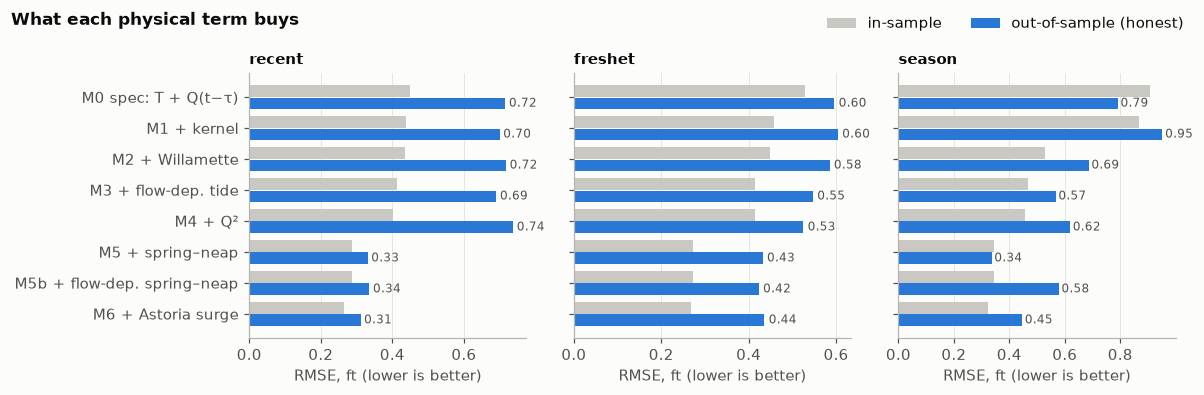

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for axi, wn in zip(ax, ["recent", "freshet", "season"]):
    t = ladder.loc[wn]
    y = np.arange(len(t))[::-1]
    axi.barh(y + 0.2, t["RMSE in (ft)"], height=0.38, color="#c9c8c2", label="in-sample")
    axi.barh(y - 0.2, t["RMSE out (ft)"], height=0.38, color=C["model"], label="out-of-sample (honest)")
    for yi, v in zip(y, t["RMSE out (ft)"]):
        axi.text(v + 0.01, yi - 0.2, f"{v:.2f}", va="center", fontsize=8, color=C["muted"])
    axi.set_yticks(y, [m.replace("flow-dependent", "flow-dep.").replace("response ", "") for m in t.index])
    axi.set_title(wn)
    axi.set_xlabel("RMSE, ft (lower is better)")
    axi.grid(axis="y", visible=False)
fig.suptitle("What each physical term buys", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.legend(*ax[0].get_legend_handles_labels(), loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.0))
savefig(fig, "07_ladder")

**Reading the ladder** (out-of-sample RMSE is the number to trust):

* **M0, as specified, isn't good enough:** out-of-sample RMSE 0.6–0.8 ft, R² ≈ 0.53–0.68.
* **Willamette (M2)** matters over the season (0.79 → 0.69 ft); in any single month it
  changes too little to identify.
* **Flow-dependent tide (M3)** helps in every window. The NOAA tide is the wrong size and
  timing for the current flow (Section 8a).
* **Q² (M4)** is mixed: a small gain in the freshet, a small loss elsewhere. It's kept
  because the physics (ocean-controlled at low flow, friction-controlled at high flow)
  says the response *must* be curved over a full year; a longer record should confirm it.
* **Spring–neap setup (M5) is the single biggest improvement:** out-of-sample RMSE drops
  by roughly half (0.74 → 0.33 ft recent; 0.62 → 0.34 ft season). Over days, the river's
  mean level at Vancouver rises and falls with the fortnightly tide cycle. This is a known
  Columbia estuary effect, and our "slow residual" was mostly this.
* **M5b** (spring–neap strength varying with flow) doesn't help: in-sample fit unchanged,
  season out-of-sample worse. Rejected.
* **M6 (Astoria surge)** helps slightly in-sample but hurts the season out-of-sample.
  Summer 2026 had little storm surge to learn from. Re-test with winter data before
  including it.

**Recommended: M5.** Season out-of-sample R² 0.92, RMSE 0.34 ft.

**Coefficients of the season-long M5 fit, with physical readings.** The Bonneville
sensitivity dh/dQ = b + 2·b₂·Q/100² is not constant because of the Q² term. The tide
gain and timing shift both vary with flow.

In [17]:
BEST = "M5 + spring–neap"  # recommended model; see the ladder discussion for why not M6
tau, w, sl, beta, d = fits[("season (Mar 1–Sep 23)", BEST)]
print(f"lag τ = {tau} h, kernel width w = {w} h, centroid lag = {tau + (w - 1) / 2:.1f} h")
print(beta.round(4).to_string())
for Q in (80, 150, 250):
    dhdq = beta["q"] + 2 * beta["q2"] * Q / 100 ** 2
    g = np.hypot(beta["T"] + beta["Tq"] * Q / 100, beta["HT"] + beta["HTq"] * Q / 100)
    ph = np.degrees(np.arctan2(beta["HT"] + beta["HTq"] * Q / 100, beta["T"] + beta["Tq"] * Q / 100))
    print(f"Q_BON = {Q:3d} kcfs: +10 kcfs at Bonneville → {10 * dhdq:+.2f} ft here;  "
          f"tide gain vs NOAA {g:.2f}, phase shift {ph:+.0f}° (≈ {ph / 360 * 12.42 * 60:+.0f} min on M2)")
print(f"Willamette: +10 kcfs → {10 * beta['qw']:+.2f} ft;  "
      f"spring–neap: +0.1 ft of predicted tidal amplitude → {0.1 * beta['sn']:+.2f} ft of mean level")

lag τ = 0 h, kernel width w = 24 h, centroid lag = 11.5 h
const    0.7612
T        2.1121
Tq      -0.6188
HT      -0.2826
HTq      0.1982
q        0.0078
q2       0.4832
qw       0.0548
sn       2.8639
Q_BON =  80 kcfs: +10 kcfs at Bonneville → +0.16 ft here;  tide gain vs NOAA 1.62, phase shift -4° (≈ -9 min on M2)
Q_BON = 150 kcfs: +10 kcfs at Bonneville → +0.22 ft here;  tide gain vs NOAA 1.18, phase shift +1° (≈ +1 min on M2)
Q_BON = 250 kcfs: +10 kcfs at Bonneville → +0.32 ft here;  tide gain vs NOAA 0.60, phase shift +21° (≈ +43 min on M2)
Willamette: +10 kcfs → +0.55 ft;  spring–neap: +0.1 ft of predicted tidal amplitude → +0.29 ft of mean level


All signs are physical: more flow raises the river; more Willamette raises it; spring
tides raise the mean level. The Bonneville sensitivity roughly doubles from low to high
flow (≈ 0.16 → 0.32 ft per 10 kcfs). The tide at Vancouver is ~1.6× NOAA's prediction at
late-summer low flow and ~0.6× in a freshet, arriving ~40 min later than predicted.

**Caveat on coefficients.** The regressors are correlated (Bonneville, Willamette and
season all co-vary), so individual coefficients are less certain than the overall fit.
Standard errors would be misleading here because residuals are strongly autocorrelated.
Fitting on several years (more independent freshets) is the real fix.

### Component view of M5 (season fit, shown for the recent window)

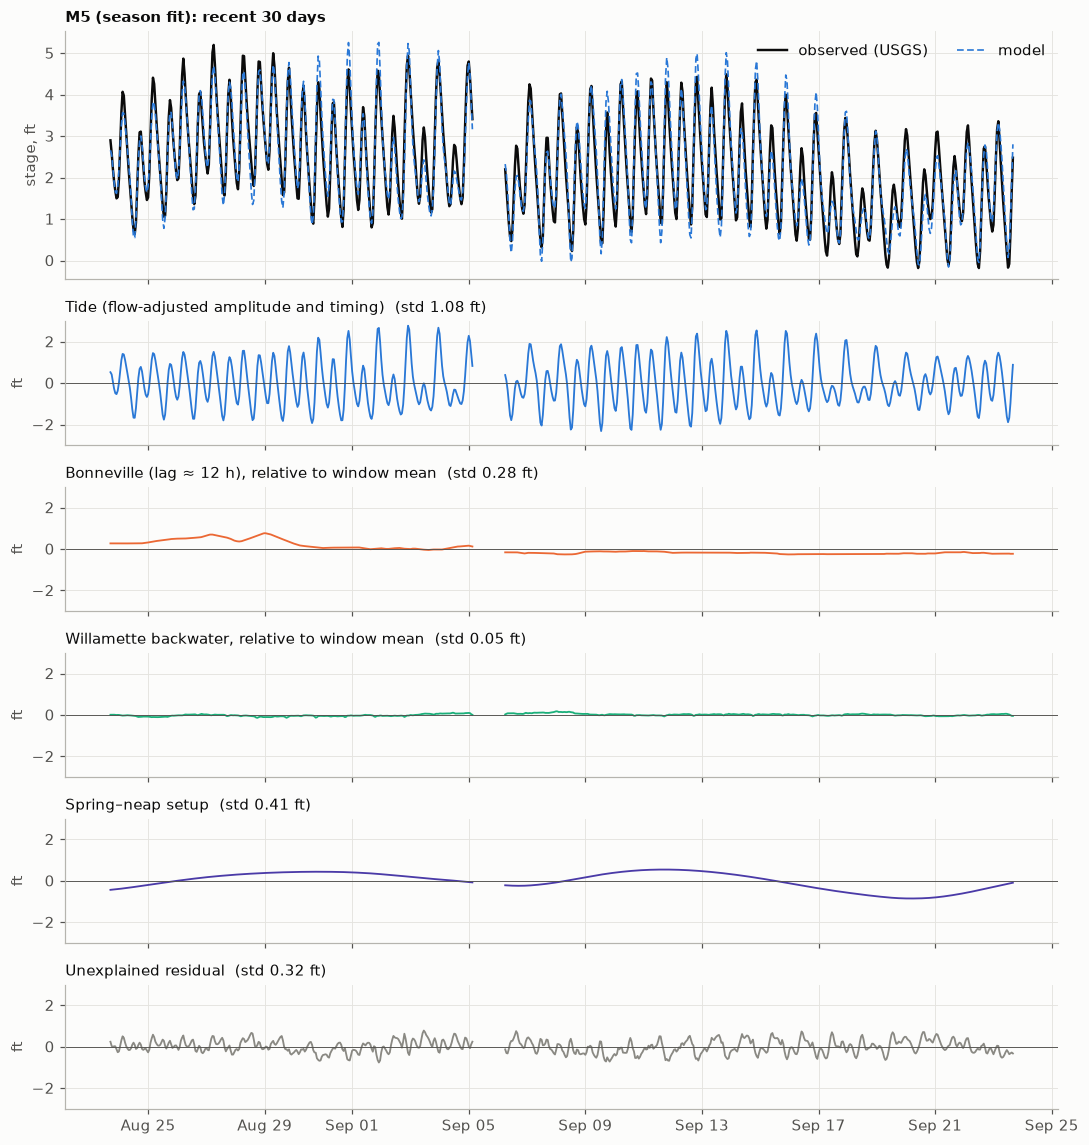

In [18]:
parts = {
    "tide": ["T", "Tq", "HT", "HTq"], "sn": ["sn"], "bon": ["q", "q2"], "wil": ["qw"],
}


def components(beta, d):
    out = {k: (d[v] * beta[v]).sum(axis=1, min_count=len(v)) for k, v in parts.items() if v[0] in beta}
    out = pd.DataFrame(out)
    out["model"] = predict(beta, d)
    out["resid"] = d.y - out["model"]
    return out


comp = components(beta, d)
a, b = W["recent (Aug 24–Sep 23)"]
cr = comp[a:b]
component_figure("recent", [
    ("Tide (flow-adjusted amplitude and timing)", cr.tide, C["tide"]),
    (f"Bonneville (lag ≈ {tau + (w - 1) / 2:.0f} h), relative to window mean", cr.bon - cr.bon.mean(), C["bon"]),
    ("Willamette backwater, relative to window mean", cr.wil - cr.wil.mean(), C["wil"]),
    ("Spring–neap setup", cr.sn - cr.sn.mean(), C["sn"]),
    ("Unexplained residual", cr.resid, C["resid"]),
], d.y[a:b], cr.model, "M5 (season fit): recent 30 days", "07_best_components_recent");

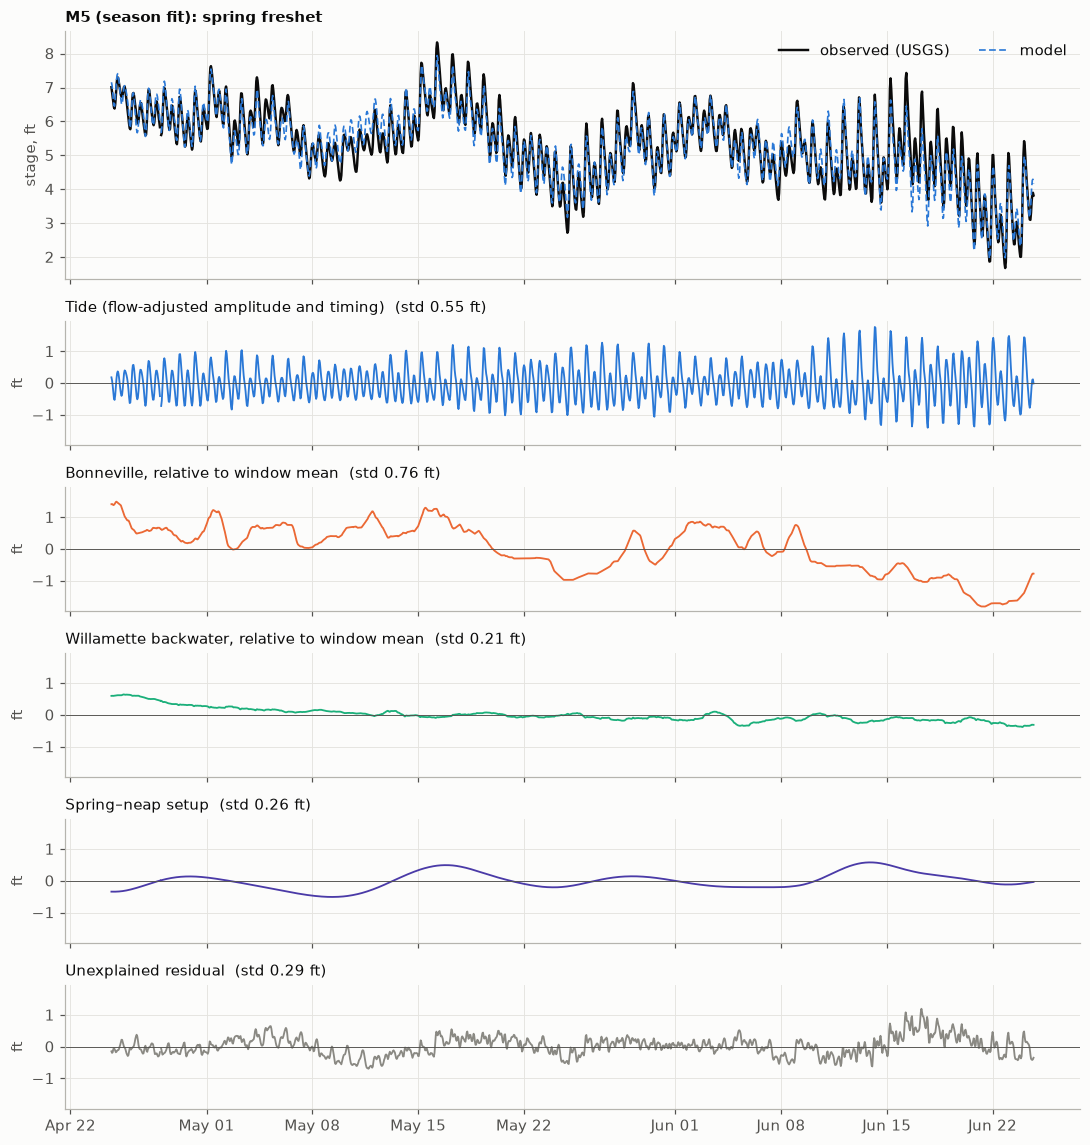

In [19]:
a, b = W["freshet (Apr 25–Jun 25)"]
cr = comp[a:b]
component_figure("freshet", [
    ("Tide (flow-adjusted amplitude and timing)", cr.tide, C["tide"]),
    ("Bonneville, relative to window mean", cr.bon - cr.bon.mean(), C["bon"]),
    ("Willamette backwater, relative to window mean", cr.wil - cr.wil.mean(), C["wil"]),
    ("Spring–neap setup", cr.sn - cr.sn.mean(), C["sn"]),
    ("Unexplained residual", cr.resid, C["resid"]),
], d.y[a:b], cr.model, "M5 (season fit): spring freshet", "07_best_components_freshet");

## 8. Where the model breaks down

**8a. NOAA's tide predictions degrade with flow.** Every 3 days across the season, regress
the observed tidal part of stage (stage minus its Godin low-pass) on NOAA's tidal
oscillation and its quadrature. That gives the observed tide's size (gain) and timing
(phase) relative to NOAA's prediction. Plot both against Bonneville flow.

Q             1.00
gain         -0.94
phase_min     0.74
naive_rmse   -0.49
Name: Q, dtype: float64

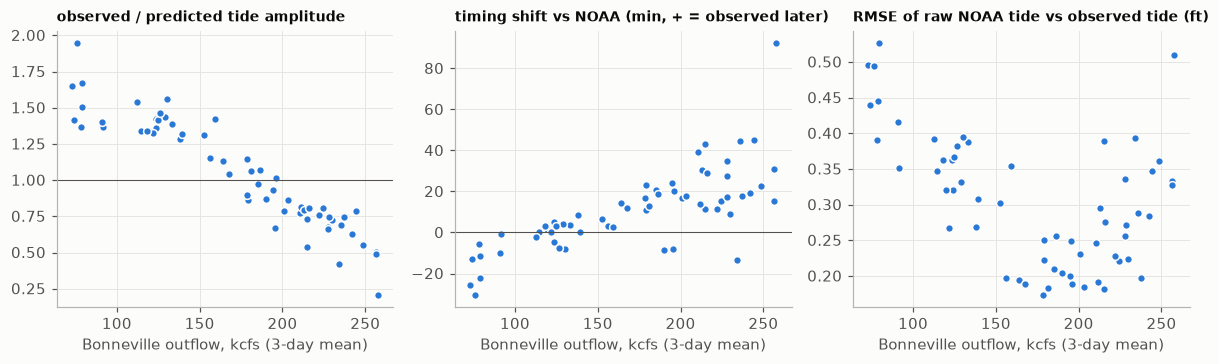

In [20]:
obs_tidal = stage - godin(stage)
blocks = []
for t0 in pd.date_range(H[48], H[-48], freq="3D"):
    blk = pd.DataFrame({"y": obs_tidal, "T": tide_osc, "HT": tide_q})[t0:t0 + pd.Timedelta("3D")].dropna()
    if len(blk) < 60:
        continue
    X = np.column_stack([blk["T"], blk["HT"]])
    (ga, gp), *_ = np.linalg.lstsq(X, blk.y, rcond=None)
    naive = rmse(blk.y, blk["T"])  # error if you used NOAA's tide as-is
    blocks.append({"t": t0, "Q": bon[t0:t0 + pd.Timedelta("3D")].mean(), "gain": np.hypot(ga, gp),
                   "phase_min": np.degrees(np.arctan2(gp, ga)) / 360 * 12.42 * 60, "naive_rmse": naive})
blocks = pd.DataFrame(blocks)

fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
for axi, col, lab in zip(ax, ["gain", "phase_min", "naive_rmse"],
                         ["observed / predicted tide amplitude", "timing shift vs NOAA (min, + = observed later)",
                          "RMSE of raw NOAA tide vs observed tide (ft)"]):
    axi.scatter(blocks.Q, blocks[col], s=26, color=C["tide"], edgecolor="#fcfcfb", linewidth=1)
    axi.set_xlabel("Bonneville outflow, kcfs (3-day mean)")
    axi.set_title(lab, fontsize=9)
ax[0].axhline(1, color=C["muted"], lw=0.7)
ax[1].axhline(0, color=C["muted"], lw=0.7)
fig.tight_layout()
savefig(fig, "08_tide_vs_flow")
blocks[["Q", "gain", "phase_min", "naive_rmse"]].corr().loc["Q"].round(2)

**NOAA's river-tide predictions are only right at middling flow.** The observed/predicted
amplitude ratio falls almost linearly with Bonneville flow (correlation −0.94): ≈ 1.5–1.9
below 100 kcfs, ≈ 1.0 near 170 kcfs, ≈ 0.5 above 250 kcfs. Timing slips from ~20 min
*early* at low flow to ~20–45 min *late* at high flow (one outlier near +90 min). Using
NOAA's tide as-is would be off by up to ~0.5 ft. The M3 terms correct both size and
timing; that is what makes the "tide" component trustworthy.

A big freshet (Bonneville > 400 kcfs, e.g. 2011 or 2017) would damp the tide further. The
highest 2026 hourly flow was ~296 kcfs (mid-March), so behavior beyond that is
extrapolation.

**8b. Residual error by flow regime** (season M5 fit):

In [21]:
res = pd.DataFrame({"resid": comp.resid, "Q": bon}).dropna()
res["flow band"] = pd.cut(res.Q, [0, 100, 150, 200, 250, 400],
                          labels=["<100", "100–150", "150–200", "200–250", ">250"])
by = res.groupby("flow band", observed=True).resid.agg(
    hours="size", bias_ft="mean", rmse_ft=lambda x: np.sqrt((x ** 2).mean()),
    p95_abs_ft=lambda x: x.abs().quantile(0.95)).round(3)
by

,hours,bias_ft,rmse_ft,p95_abs_ft
flow band,,,,
<100,553,-0.011,0.331,0.628
100–150,1404,0.014,0.329,0.638
150–200,1052,-0.040,0.336,0.631
200–250,1434,0.025,0.348,0.678
>250,365,-0.020,0.411,0.937


Error is nearly flat across flow bands (RMSE ≈ 0.33 ft) and unbiased, until flows exceed
250 kcfs, where RMSE rises to ~0.41 ft and the 95th-percentile miss nearly reaches 1 ft.
That's where the model starts to break down, and only 365 hours of this season are in
that band.

**8c. What's left in the residual?** Its power spectrum shows whether the leftover is
tidal (model structure), daily, or slow (missing drivers):

slow (> 3 days)          67%
diurnal (20–30 h)        15%
semidiurnal (11–14 h)     3%
overtides (< 9 h)        11%
Name: share of residual variance, dtype: str

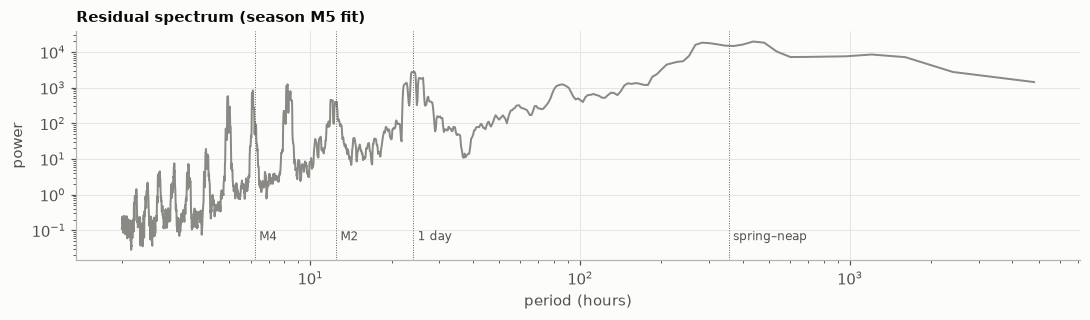

In [22]:
r_ = fill_short_gaps(comp.resid, 6).dropna()
r_ = r_ - r_.mean()
f = np.fft.rfftfreq(len(r_), d=1.0)  # cycles/hour
p = np.abs(np.fft.rfft(r_.to_numpy() * np.hanning(len(r_)))) ** 2
sp = pd.Series(p[1:], index=1 / f[1:]).sort_index()
bands = {"slow (> 3 days)": sp[sp.index > 72].sum(), "diurnal (20–30 h)": sp[(sp.index > 20) & (sp.index <= 30)].sum(),
         "semidiurnal (11–14 h)": sp[(sp.index > 11) & (sp.index <= 14)].sum(), "overtides (< 9 h)": sp[sp.index < 9].sum()}
tot = sp.sum()
fig, ax = plt.subplots(figsize=(10, 3))
ax.loglog(sp.index, sp.rolling(9, center=True, min_periods=1).mean(), color=C["resid"])
for per, lab in [(12.42, "M2"), (24, "1 day"), (24 * 14.77, "spring–neap"), (6.21, "M4")]:
    ax.axvline(per, color=C["muted"], lw=0.6, ls=":")
    ax.text(per * 1.04, ax.get_ylim()[0] * 3, lab, fontsize=8, color=C["muted"], ha="left", va="bottom")
ax.set(xlabel="period (hours)", ylabel="power", title="Residual spectrum (season M5 fit)")
fig.tight_layout()
savefig(fig, "08_resid_spectrum")
pd.Series({k: f"{100 * v / tot:.0f}%" for k, v in bands.items()}, name="share of residual variance")

Two-thirds of what's left is **slow** (multi-day): unmodeled drivers such as smaller
tributaries (Sandy, Lewis, Cowlitz backwater), ocean setup, and Columbia flow entering
below Bonneville. About 15% is **daily**. Partly that's because the 24-h Bonneville kernel
averages away the dam's daily load-following cycle; partly it's diurnal tidal inequality.
About 11% is **overtides** (M4, ~6.2 h and shorter). Those are shallow-water tidal
distortions, which a linear tide term can't make. Next improvements: add `T²`-type
overtide terms, and a two-part Bonneville kernel (sharp + smeared).

## 9. Prototype production output: "why is the river moving?"

Levels need a reference, but **changes** don't. The change in stage over the last few
hours splits cleanly into changes in each component (the constant cancels). This is what
the app shows. Example at the end of the data:

In [23]:
def attribute(comp, t_end, hours):
    t0 = t_end - pd.Timedelta(hours=hours)
    c = comp[["tide", "sn", "bon", "wil", "resid"]]
    dlt = c.loc[t_end] - c.loc[t0]
    obs = stage.loc[t_end] - stage.loc[t0]
    out = dlt.rename({"tide": "tide", "sn": "spring–neap", "bon": "Bonneville", "wil": "Willamette",
                      "resid": "unexplained"})
    out["= observed change"] = obs
    return out.round(2)


t_end = comp.dropna().index[-1]
pd.DataFrame({f"last {h} h (to {local(pd.DatetimeIndex([t_end]))[0]:%b %d %H:%M} PT)": attribute(comp, t_end, h)
              for h in (3, 6, 24, 72)})

,last 3 h (to Sep 23 16:00 PT),last 6 h (to Sep 23 16:00 PT),last 24 h (to Sep 23 16:00 PT),last 72 h (to Sep 23 16:00 PT)
tide,2.56,1.98,0.03,0.45
spring–neap,0.04,0.08,0.31,0.74
Bonneville,-0.01,-0.01,-0.05,-0.00
Willamette,-0.07,-0.10,-0.03,0.01
unexplained,0.03,-0.07,-0.47,-0.79
= observed change,2.56,1.88,-0.22,0.42


The river rose 2.56 ft in the last 3 hours, and the model attributes essentially all of
it to tide, which is right for late September. This is the core app feature, and it works
at the hour scale. At 24–72 h, the "spring–neap" and "unexplained" rows are large and
partly offsetting. Multi-day attributions are less certain, and the app should say so
(for example, show "unexplained" honestly, not fold it into another bar).

## 10. NWS forecast and fish counts

**NWPS forecast.** The NWRFC issues a stage forecast for VAPW1 (tide included) about
7 days out, hourly. NWPS serves only the *current* forecast, so forecast skill can't be
checked retrospectively. Production should archive each issuance to build a skill
record over time.

flood categories (ft): {'major': 25, 'moderate': 20, 'minor': 16, 'action': 15}


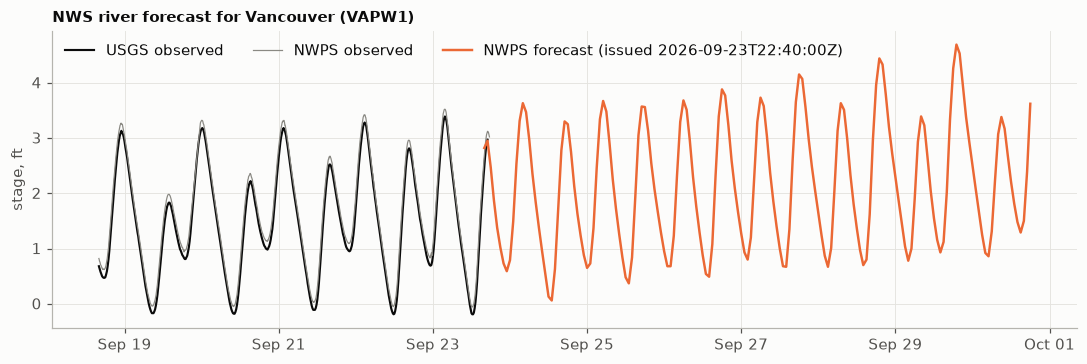

In [24]:
fig, ax = plt.subplots(figsize=(10, 3.4))
t0 = nwps_fcst.index.min() - pd.Timedelta("5D")
ax.plot(local(stage15.value[t0:].index), stage15.value[t0:], color=C["obs"], lw=1.4, label="USGS observed")
ax.plot(local(nwps_obs[t0:].index), nwps_obs[t0:], color=C["resid"], lw=0.8, label="NWPS observed")
ax.plot(local(nwps_fcst.index), nwps_fcst, color=C["bon"], lw=1.6, label=f"NWPS forecast (issued {nwps_fcst.attrs['issuedTime']})")
ax.set(title="NWS river forecast for Vancouver (VAPW1)", ylabel="stage, ft")
ax.legend(loc="upper left", ncol=3)
fmt_dates(ax)
fig.tight_layout()
savefig(fig, "10_nwps")
print("flood categories (ft):", {k: v["stage"] for k, v in nwps_meta["flood"]["categories"].items()})

**DART adult passage at Bonneville.** Daily counts by species plus DART's 10-year average
for the same day:

In [25]:
sp_cols = {"Chin": "Chinook (adult)", "JChin": "Chinook (jack)", "Stlhd": "Steelhead", "Coho": "Coho",
           "Sock": "Sockeye", "Shad": "Shad", "LmpryDay": "Lamprey (daytime)"}
last = fish["Chin"].last_valid_index()
wk = fish.loc[last - pd.Timedelta("6D"):last]
tbl = pd.DataFrame({
    "last 7 days": {v: wk[k].sum() for k, v in sp_cols.items()},
    "10-yr avg, same days": {v: wk.get(k + "10Yr", pd.Series(dtype=float)).sum() for k, v in sp_cols.items()},
    "year to date": {v: fish.loc[:last, k].sum() for k, v in sp_cols.items()},
    "10-yr avg YTD": {v: fish.loc[:last].get(k + "10Yr", pd.Series(dtype=float)).sum() for k, v in sp_cols.items()},
})
tbl["% of 10-yr (7 d)"] = (100 * tbl["last 7 days"] / tbl["10-yr avg, same days"].replace(0, np.nan)).round(0)
tlast = fish["TempC"].last_valid_index()
print(f"counts through {last:%Y-%m-%d}; fish-ladder water temperature {fish.loc[tlast, 'TempC']} °C on {tlast:%Y-%m-%d}")
tbl.astype({"last 7 days": int, "year to date": int})

counts through 2026-09-22; fish-ladder water temperature 20.2 °C on 2026-09-09


,last 7 days,"10-yr avg, same days",year to date,10-yr avg YTD,% of 10-yr (7 d)
Chinook (adult),41123,45963.0,540689,518198.0,89.0
Chinook (jack),11250,8682.0,130843,72901.0,130.0
Steelhead,1626,8777.0,61226,112691.0,19.0
Coho,9388,15812.0,58348,74694.0,59.0
Sockeye,0,0.0,74033,309404.0,NaN
Shad,0,0.0,2800954,4685362.0,NaN
Lamprey (daytime),23,45.0,13715,38248.0,51.0


## Summary

See `README.md` for the written findings and the recommended production approach.